# Лабораторная работа №1
## Первичное исследование и оценка качества данных

**Датасет:** `synthetic_healthcare_data.csv` — синтетические данные о госпитализациях пациентов.

---
## 1. Постановка задачи

### 1.1. Что это за данные
Датасет содержит 500 записей о госпитализациях пациентов. Каждая запись включает демографические сведения (возраст, пол), клинические показатели (индекс массы тела, артериальное давление, уровень холестерина), факторы риска (курение, диабет), диагноз, стоимость лечения, даты поступления и выписки, а также исход лечения. Данные носят синтетический характер и предназначены для учебного анализа. Признаки смешанных типов: числовые, категориальные, бинарные и временные.

### 1.2. Условный заказчик
Аналитический отдел сети клиник (или страховая компания), заинтересованный в оценке качества медицинской помощи, оптимизации затрат и выявлении факторов, влияющих на исход лечения.

### 1.3. Возможные задачи интеллектуального анализа данных
1. **Описательная аналитика** — профилирование групп пациентов по диагнозам, возрасту и факторам риска; поиск закономерностей между показателями и исходом.
2. **Поиск аномалий** — выявление подозрительно высоких/низких стоимостей лечения, аномальных значений артериального давления и ИМТ.
3. **(Дополнительно) Сегментация пациентов** — кластеризация по клиническому профилю для персонализации лечения.
4. **(Дополнительно) Прогнозирование исхода лечения** — классификация (`Recovered` / `Referred` / `Deceased`).

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
print("Библиотеки успешно загружены.")

Библиотеки успешно загружены.


---
## 2. Паспорт датасета

**Смысл признаков (гипотеза по названию):**

| Признак | Смысл |
|---|---|
| `Patient_ID` | Уникальный идентификатор |
| `Age` | Возраст, лет |
| `Gender` | Пол |
| `BMI` | Индекс массы тела |
| `Blood_Pressure` | АД «сист / диаст» (строка) |
| `Cholesterol_Level` | Холестерин |
| `Smoker` / `Diabetic` | Факторы риска (Yes/No) |
| `Diagnosis` | Диагноз |
| `Treatment_Cost` | Стоимость лечения |
| `Admission_Date` / `Discharge_Date` | Даты поступления и выписки |
| `Outcome` | Исход |

In [2]:
# Загрузка
df = pd.read_csv('../data/synthetic_healthcare_data.csv')
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов\n")

# Типы и уникальные значения
display(pd.DataFrame({
    'Тип': df.dtypes.astype(str),
    'Непустых': df.notna().sum(),
    'Уникальных': df.nunique()
}))

# Преобразования:
# 1) Blood_Pressure -> BP_Systolic, BP_Diastolic
df[['BP_Systolic', 'BP_Diastolic']] = (
    df['Blood_Pressure'].str.split('/', expand=True).astype(float)
)
# 2) Даты -> datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], errors='coerce')
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'], errors='coerce')
# 3) Длительность госпитализации
df['Length_of_Stay'] = (df['Discharge_Date'] - df['Admission_Date']).dt.days

print("\nПосле преобразования:")
print(df[['BP_Systolic', 'BP_Diastolic', 'Length_of_Stay']].describe().round(2))

Размер: 500 строк × 13 столбцов



,Тип,Непустых,Уникальных
Patient_ID,str,500,500
Age,int64,500,73
Gender,str,500,2
BMI,float64,500,197
Blood_Pressure,str,500,471
Cholesterol_Level,int64,500,142
Smoker,str,500,2
Diabetic,str,500,2
Diagnosis,str,500,5
Treatment_Cost,float64,500,500



После преобразования:
       BP_Systolic  BP_Diastolic  Length_of_Stay
count       500.00        500.00          500.00
mean        135.55         91.71            7.26
std          25.95         17.98            4.07
min          90.00         60.00            1.00
25%         113.75         77.00            4.00
50%         136.50         92.50            7.00
75%         156.00        107.00           11.00
max         180.00        120.00           14.00


---
## 3. Аудит качества данных

### 3.1. Пропуски и дубликаты

In [3]:
# Пропуски
missing = pd.DataFrame({
    'Пропущено': df.isna().sum(),
    'Доля, %': (df.isna().mean() * 100).round(2)
}).sort_values('Пропущено', ascending=False)
display(missing)
print(f"Всего пропусков: {df.isna().sum().sum()}")

# Дубликаты
print(f"\nПолных дубликатов: {df.duplicated().sum()}")


cols_no_id_dates = [c for c in df.columns
                    if c not in ['Patient_ID', 'Admission_Date', 'Discharge_Date']]
dup_no_id = df.duplicated(subset=cols_no_id_dates).sum()
print(f"\nДубликатов без учёта Patient_ID и дат: {dup_no_id}")



,Пропущено,"Доля, %"
Patient_ID,0,0.0
Age,0,0.0
Gender,0,0.0
BMI,0,0.0
Blood_Pressure,0,0.0
Cholesterol_Level,0,0.0
Smoker,0,0.0
Diabetic,0,0.0
Diagnosis,0,0.0
Treatment_Cost,0,0.0


Всего пропусков: 0

Полных дубликатов: 0

Дубликатов без учёта Patient_ID и дат: 0


### 3.2. Типические проблемы значений

In [4]:
# Числовые: описательная статистика
num_cols = ['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost',
            'BP_Systolic', 'BP_Diastolic', 'Length_of_Stay']
display(df[num_cols].describe().T.round(2))

# Категориальные
for col in ['Gender', 'Smoker', 'Diabetic', 'Diagnosis', 'Outcome']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

# Подозрительные значения
print("\n=== Диастолическое >= систолического ===")
bad_bp = df[df['BP_Diastolic'] >= df['BP_Systolic']]
print(f"Найдено: {len(bad_bp)} ({len(bad_bp)/len(df)*100:.1f}%)")

print("\n=== Длительность госпитализации <= 0 ===")
print(f"Найдено: {(df['Length_of_Stay'] <= 0).sum()}")

print("\n=== Отрицательная стоимость лечения ===")
print(f"Найдено: {(df['Treatment_Cost'] < 0).sum()}")

print("\nЗначения Outcome:", sorted(df['Outcome'].unique()))

,count,mean,std,min,25%,50%,75%,max
Age,500.0,54.14,21.22,18.00,36.00,55.00,73.00,90.00
BMI,500.0,28.77,6.34,18.00,23.48,28.50,34.20,40.00
Cholesterol_Level,500.0,226.54,43.67,151.00,189.75,225.50,266.00,300.00
Treatment_Cost,500.0,2514.43,1379.50,106.04,1406.11,2538.01,3671.94,4994.04
BP_Systolic,500.0,135.55,25.95,90.00,113.75,136.50,156.00,180.00
BP_Diastolic,500.0,91.71,17.98,60.00,77.00,92.50,107.00,120.00
Length_of_Stay,500.0,7.26,4.07,1.00,4.00,7.00,11.00,14.00



--- Gender ---
Gender
Female    251
Male      249
Name: count, dtype: int64

--- Smoker ---
Smoker
No     263
Yes    237
Name: count, dtype: int64

--- Diabetic ---
Diabetic
Yes    261
No     239
Name: count, dtype: int64

--- Diagnosis ---
Diagnosis
Diabetes         115
Hypertension     106
Pneumonia        104
Heart Disease     90
Flu               85
Name: count, dtype: int64

--- Outcome ---
Outcome
Referred     178
Deceases     163
Recovered    159
Name: count, dtype: int64

=== Диастолическое >= систолического ===
Найдено: 53 (10.6%)

=== Длительность госпитализации <= 0 ===
Найдено: 0

=== Отрицательная стоимость лечения ===
Найдено: 0

Значения Outcome: ['Deceases', 'Recovered', 'Referred']


### 3.3. Выбросы (метод IQR)

IQR-границы Treatment_Cost: [-1992.65; 7070.70]
Выбросов: 0 (0.0%)


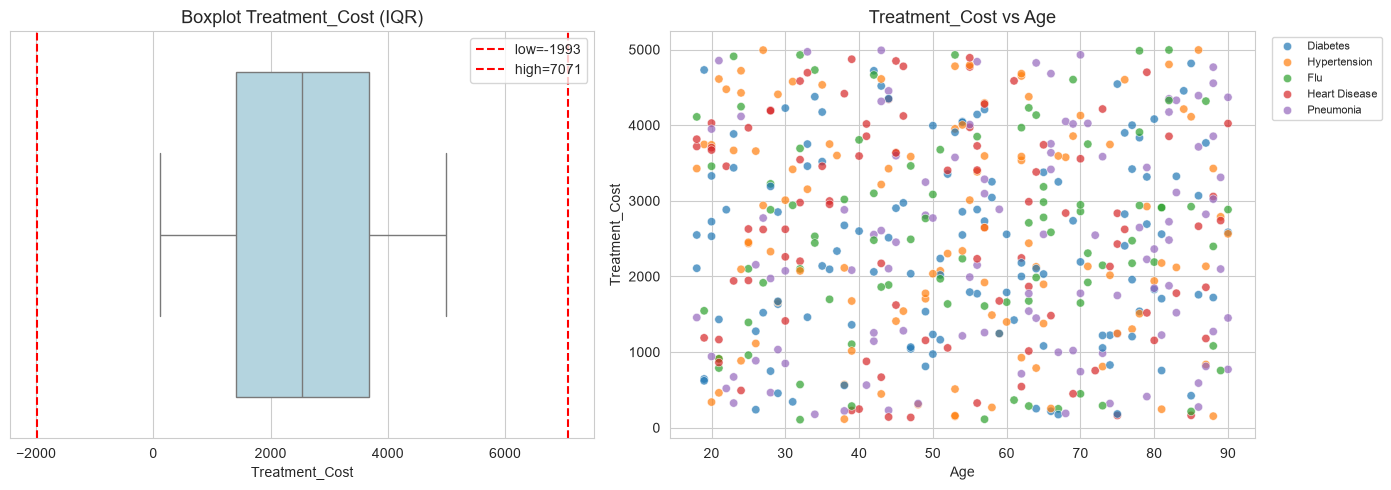

In [5]:
def iqr_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return (s < lo) | (s > hi), lo, hi

mask, lo, hi = iqr_outliers(df['Treatment_Cost'])
print(f"IQR-границы Treatment_Cost: [{lo:.2f}; {hi:.2f}]")
print(f"Выбросов: {mask.sum()} ({mask.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df['Treatment_Cost'], ax=axes[0], color='lightblue')
axes[0].axvline(lo, color='red', ls='--', label=f'low={lo:.0f}')
axes[0].axvline(hi, color='red', ls='--', label=f'high={hi:.0f}')
axes[0].set_title('Boxplot Treatment_Cost (IQR)')
axes[0].legend()

sns.scatterplot(data=df, x='Age', y='Treatment_Cost',
                hue='Diagnosis', ax=axes[1], alpha=0.7)
axes[1].set_title('Treatment_Cost vs Age')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Разведочный анализ

### 4.1. Распределения

C:\Users\саша\AppData\Local\Temp\ipykernel_16288\3040238643.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Diagnosis', order=order, ax=axes[1], palette='viridis')


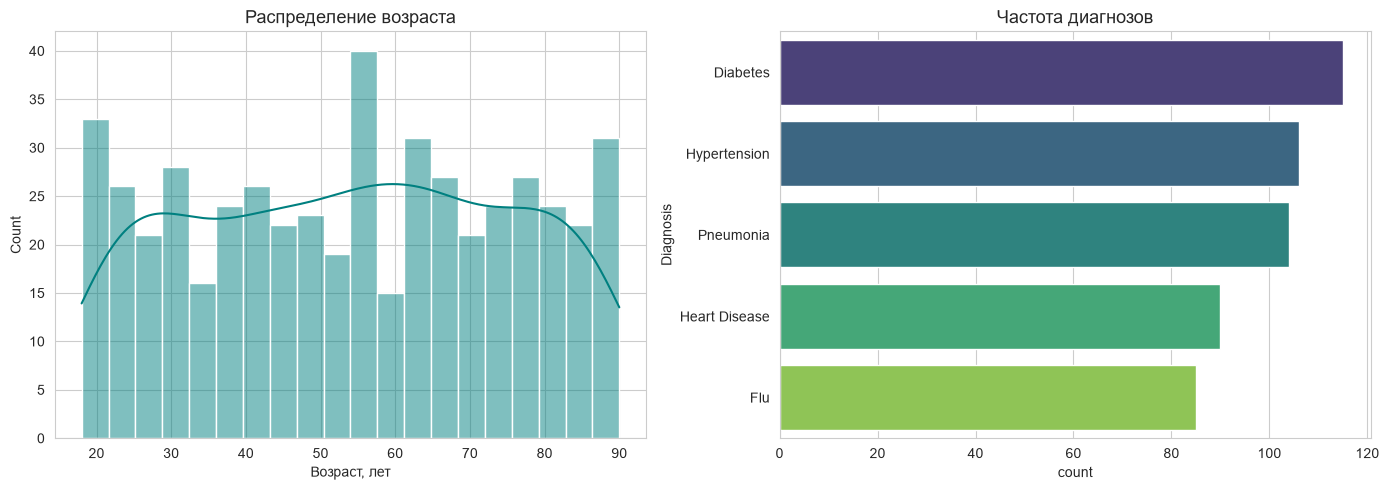

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Возраст, лет')

order = df['Diagnosis'].value_counts().index
sns.countplot(data=df, y='Diagnosis', order=order, ax=axes[1], palette='viridis')
axes[1].set_title('Частота диагнозов')

plt.tight_layout()
plt.show()


# Возраст распределён почти равномерно с медианой ~55 лет.
# Диагнозы сбалансированы, слегка преобладают Hypertension и Diabetes.
# Гипотеза: датасет сгенерирован равномерно, без смещений по возрасту.

### 4.2. Зависимости между признаками

C:\Users\саша\AppData\Local\Temp\ipykernel_16288\514142484.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y='Treatment_Cost',


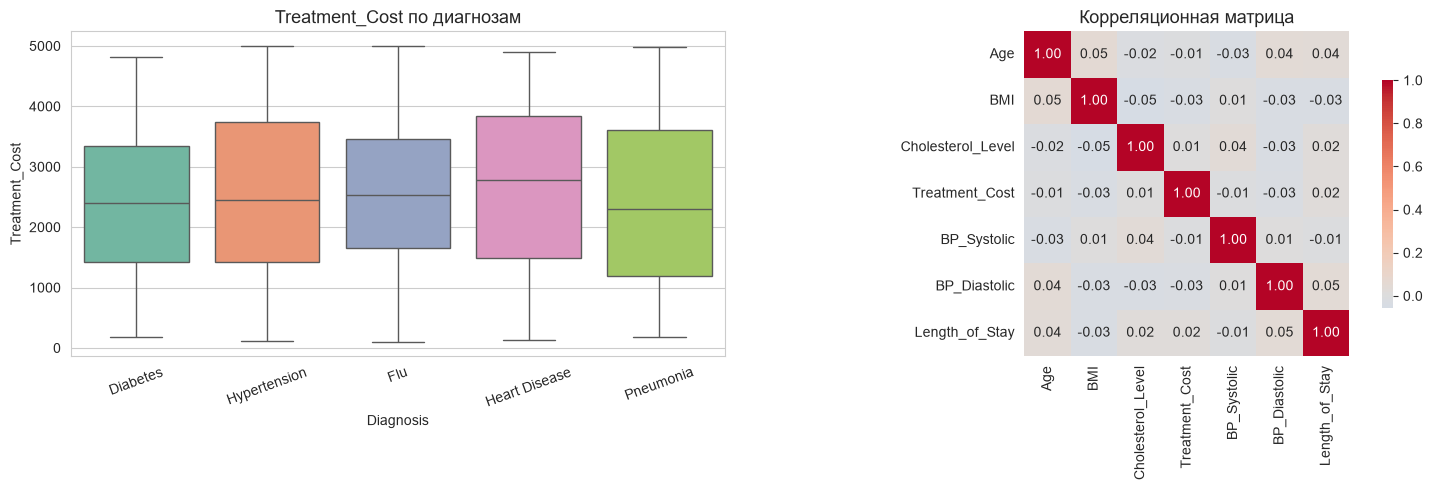

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Diagnosis', y='Treatment_Cost',
            ax=axes[0], palette='Set2')
axes[0].set_title('Treatment_Cost по диагнозам')
axes[0].tick_params(axis='x', rotation=20)

corr = df[['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost',
           'BP_Systolic', 'BP_Diastolic', 'Length_of_Stay']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], cbar_kws={'shrink': .7})
axes[1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

# Медианная стоимость лечения слабо различается между диагнозами,
# но разброс у Heart Disease и Pneumonia шире.
# Корреляции между числовыми признаками слабые — гипотеза о независимости.

# ЧАСТЬ 2. Углубленный статистический анализ (ЛР №1_1)

## Задание 1. Типы признаков и шкалы измерения

| Признак | Тип шкалы | Обоснование |
| :--- | :--- | :--- |
| `Patient_ID` | **Номинальная** | Идентификатор, математика бессмысленна |
| `Age` | **Шкала отношений** | Есть абсолютный ноль (рождение), разница и отношения имеют смысл |
| `Gender` | **Номинальная** | Категории без порядка |
| `BMI` | **Шкала отношений** | Есть абсолютный ноль, но 0 практически недостижим |
| `BP_Systolic` | **Шкала отношений** | Давление, есть абсолютный ноль |
| `BP_Diastolic` | **Шкала отношений** | Давление, есть абсолютный ноль |
| `Cholesterol_Level` | **Шкала отношений** | Есть абсолютный ноль |
| `Smoker` | **Номинальная** | Бинарная категория Yes/No |
| `Diabetic` | **Номинальная** | Бинарная категория Yes/No |
| `Diagnosis` | **Номинальная** | Категории диагнозов |
| `Treatment_Cost` | **Шкала отношений** | Деньги, есть абсолютный ноль |
| `Admission_Date` | **Интервальная** | Даты, разница имеет смысл, но нет абсолютного нуля |
| `Discharge_Date` | **Интервальная** | Даты, разница имеет смысл |
| `Length_of_Stay` | **Шкала отношений** | Дни, есть абсолютный ноль |
| `Outcome` | **Номинальная** (условно порядковая) | Исходы можно упорядочить по тяжести, но формально это категории |

### Сравнение двух признаков с разными шкалами

**Признак 1:** `Diagnosis` — номинальная.  
**Признак 2:** `Treatment_Cost` — шкала отношений.

Для `Diagnosis`:
- среднее —  методологически неверно;
- медиана —  неверно;
- мода —  корректна.

Для `Treatment_Cost`:
- среднее —  корректно;
- медиана —  корректна и устойчива к выбросам;
- мода —  технически считается, но для непрерывных денег обычно бесполезна.

**Вывод:** pandas может посчитать среднее для закодированного `Diagnosis`, но это не имеет смысла.

## Задание 2. Диагностика типа пропусков

В исходном датасете `synthetic_healthcare_data.csv` **пропусков нет**.  
Чтобы отработать методику, смоделируем пропуски в `Cholesterol_Level` по механизму **MAR**: вероятность пропуска зависит от возраста (`Age`). Чем старше пациент, тем чаще холестерин не измеряли.

Гипотезы:
1. **MCAR** — пропуски полностью случайны и не связаны ни с какими признаками.
2. **MAR** — пропуски зависят от других наблюдаемых признаков, например от `Age` или `Diagnosis`.
3. **MNAR** — пропуски зависят от самого пропущенного значения `Cholesterol_Level` (например, при высоком холестерине анализ не делали).

Доля пропусков в Cholesterol_Level: 0.196


,Age,BMI,BP_Systolic,Treatment_Cost
chol_missing,,,,
False,50.18,28.87,135.78,2563.73
True,70.40,28.38,134.62,2312.18



Доля пропусков по возрастным группам (%):
age_group
18-30     1.1
31-45     2.1
46-60    16.2
61-75    40.6
76-90    34.6
Name: chol_missing, dtype: float64


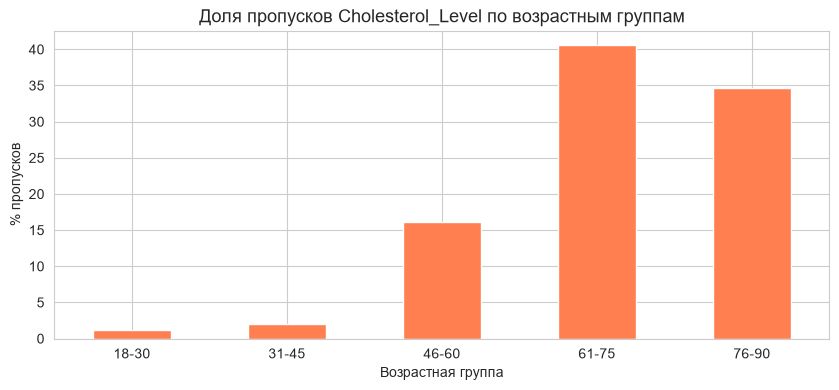

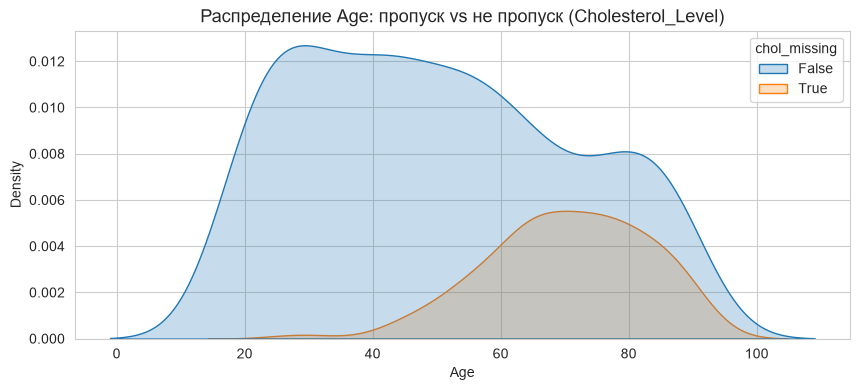


Корреляция пропуска с Age:
                Age  chol_missing
Age           1.000         0.379
chol_missing  0.379         1.000


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(RANDOM_STATE)
df_miss = df.copy()

# Симулируем MAR: вероятность пропуска Cholesterol_Level растёт с возрастом
prob_missing = 1 / (1 + np.exp(-(df_miss['Age'] - 60) / 10)) * 0.5
df_miss['chol_missing'] = np.random.binomial(1, prob_missing).astype(bool)
df_miss.loc[df_miss['chol_missing'], 'Cholesterol_Level'] = np.nan

print(f"Доля пропусков в Cholesterol_Level: {df_miss['chol_missing'].mean():.3f}")

# MCAR-проверка: сравниваем средние по другим признакам
display(
    df_miss.groupby('chol_missing')[['Age', 'BMI', 'BP_Systolic', 'Treatment_Cost']]
    .mean()
    .round(2)
)

# MAR-проверка: доля пропусков по возрастным группам
df_miss['age_group'] = pd.cut(
    df_miss['Age'],
    bins=[18, 30, 45, 60, 75, 90],
    labels=['18-30', '31-45', '46-60', '61-75', '76-90']
)
missing_by_age = df_miss.groupby('age_group', observed=False)['chol_missing'].mean() * 100
print("\nДоля пропусков по возрастным группам (%):")
print(missing_by_age.round(1))

plt.figure(figsize=(10, 4))
missing_by_age.plot(kind='bar', color='coral')
plt.title('Доля пропусков Cholesterol_Level по возрастным группам')
plt.ylabel('% пропусков')
plt.xlabel('Возрастная группа')
plt.xticks(rotation=0)
plt.show()

# KDE: видно, что пропуски смещены в сторону старшего возраста — это MAR
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_miss, x='Age', hue='chol_missing', fill=True)
plt.title('Распределение Age: пропуск vs не пропуск (Cholesterol_Level)')
plt.show()

# MNAR-проверка: если бы пропуски зависели от самого холестерина,
# то распределение Cholesterol для пропусков и не-пропусков различалось бы.
# При MAR это не проверяется напрямую, но можно смотреть корреляцию пропуска с Age.
print("\nКорреляция пропуска с Age:")
print(df_miss[['Age', 'chol_missing']].corr().round(3))

**Вывод по природе пропусков:**
- Поскольку мы специально смоделировали зависимость от `Age`, данные соответствуют **MAR**.
- Если бы доля пропусков не зависела от возраста и других признаков — это была бы **MCAR**.
- Если бы пропуски были связаны с самим уровнем холестерина (например, при высоком холестерине анализ не делали) — это была бы **MNAR**.

## Задание 3. Индикатор пропуска как источник информации

### 3.1. Когда пропуск несёт информацию?
Пропуск несёт информацию, когда сам факт его наличия коррелирует с целевой переменной.  
Пример: если холестерин не измеряли у пожилых пациентов, то индикатор пропуска может косвенно указывать на возраст и риск.

### 3.2. Почему значимость индикатора — сигнал о плохой импутации?
Если вы заполнили пропуски средним, а индикатор пропуска всё равно значим в модели, значит сам факт пропуска объясняет целевую переменную лучше, чем заполненное значение. Импутация «размыла» информацию.

### 3.3. Примеры для нашего датасета
- **Полезен:** `Cholesterol_Level` — если пропуск связан с возрастом или диагнозом.
- **Бесполезен:** `Patient_ID` — пропуск здесь просто ошибка ввода.
- **Опасен:** `Outcome` — если пропуск означает, что исход неизвестен, его нельзя заменять на «Recovered».

In [9]:
q99 = df['Treatment_Cost'].quantile(0.99)
outliers = df[df['Treatment_Cost'] > q99]

print(f"99-й перцентиль Treatment_Cost: {q99:.2f}")
print(f"Количество значений выше 99-го перцентиля: {len(outliers)}")
display(
    outliers[['Patient_ID', 'Age', 'Diagnosis', 'Treatment_Cost', 'Length_of_Stay']]
    .sort_values('Treatment_Cost', ascending=False)
    .head(10)
)

99-й перцентиль Treatment_Cost: 4969.80
Количество значений выше 99-го перцентиля: 5


,Patient_ID,Age,Diagnosis,Treatment_Cost,Length_of_Stay
78,P079,82,Flu,4994.04,2
338,P339,86,Hypertension,4993.90,10
466,P467,27,Hypertension,4992.09,4
459,P460,43,Pneumonia,4989.45,4
402,P403,78,Flu,4983.26,1


## Задание 4. Выброс — это ошибка или сигнал?

Выбранный признак: `Treatment_Cost`.  
Найденный условный выброс: значения выше 99-го перцентиля.

### 4.1. Реальные причины
- **Реальная сложная операция** — высокая стоимость лечения.
- **Длительная госпитализация** — больше дней, больше затрат.
- **Ошибка ввода** — маловероятна, но возможна.
- **Редкий диагноз** — например, Heart Disease может требовать дорогого лечения.

### 4.2. Что хуже для анализа?
- **Удалить:**  плохо, потеряем информацию о дорогих случаях.
- **Оставить без изменений:**  лучше, если значения реалистичны.
- **Применить преобразование:**  логарифмирование может помочь, если распределение сильно скошено, но интерпретация усложняется.

## Задание 5. Преобразование или винизоризация?

### 5.1. Когда что применять
- **Логарифмирование:** при сильной правосторонней асимметрии (доходы, стоимости). Хорошо для линейных моделей.
- **Корень:** более мягкое преобразование, подходит для умеренной асимметрии.
- **Винизоризация:** ограничивает влияние экстремальных значений, но не меняет форму распределения.

### 5.2. Влияние на анализ
- **Интерпретируемость:** логарифм и корень усложняют интерпретацию. Винизоризация сохраняет её.
- **Линейные модели:** логарифм и корень делают связь более линейной. Винизоризация уменьшает влияние выбросов.
- **Визуализация:** логарифм делает распределение симметричнее. Винизоризация «обрезает» хвосты.

В нашем датасете сильной асимметрии нет, поэтому преобразования не обязательны. Но для `Treatment_Cost` можно попробовать логарифм, если модель требует нормальности.

## Задание 6. Средние, которые вводят в заблуждение

Для одного числового признака сравним арифметическое среднее, медиану и (если возможно) геометрическое среднее. Объясним, почему они различаются и какое из них лучше отражает «типичное» значение.

Асимметрия Treatment_Cost: -0.01
Арифметическое среднее: 2514.43
Медиана: 2538.01
Геометрическое среднее: 1953.89


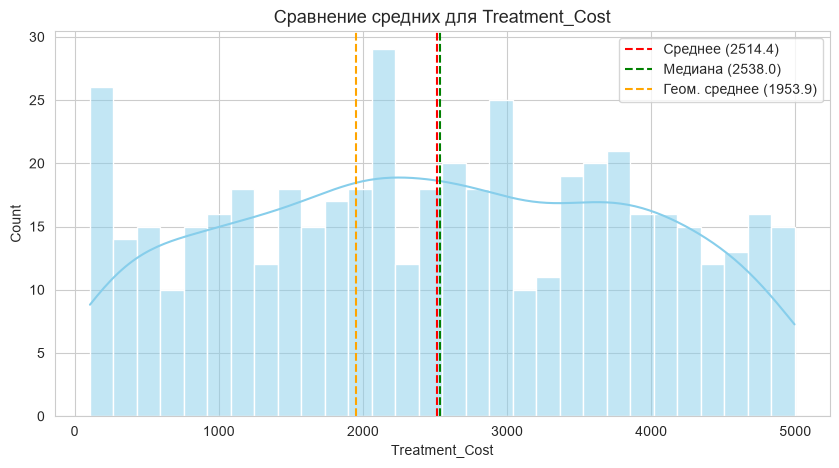

In [10]:
from scipy.stats import skew

feature = 'Treatment_Cost'
skewness = skew(df[feature].dropna())
arithmetic_mean = df[feature].mean()
median = df[feature].median()
geometric_mean = np.exp(np.mean(np.log(df[feature].dropna())))

print(f"Асимметрия {feature}: {skewness:.2f}")
print(f"Арифметическое среднее: {arithmetic_mean:.2f}")
print(f"Медиана: {median:.2f}")
print(f"Геометрическое среднее: {geometric_mean:.2f}")

plt.figure(figsize=(10, 5))
sns.histplot(df[feature], bins=30, kde=True, color='skyblue')
plt.axvline(arithmetic_mean, color='red', linestyle='--', label=f'Среднее ({arithmetic_mean:.1f})')
plt.axvline(median, color='green', linestyle='--', label=f'Медиана ({median:.1f})')
plt.axvline(geometric_mean, color='orange', linestyle='--', label=f'Геом. среднее ({geometric_mean:.1f})')
plt.title(f'Сравнение средних для {feature}')
plt.xlabel(feature)
plt.legend()
plt.show()

**Объяснение различий:**
- Если распределение симметричное, арифметическое среднее, медиана и геометрическое среднее близки.
- Если есть правосторонняя асимметрия, среднее выше медианы.
- Медиана лучше отражает «типичное» значение при выбросах.
- Геометрическое среднее полезно для мультипликативных данных.

## Задание 7. Неправильная диаграмма


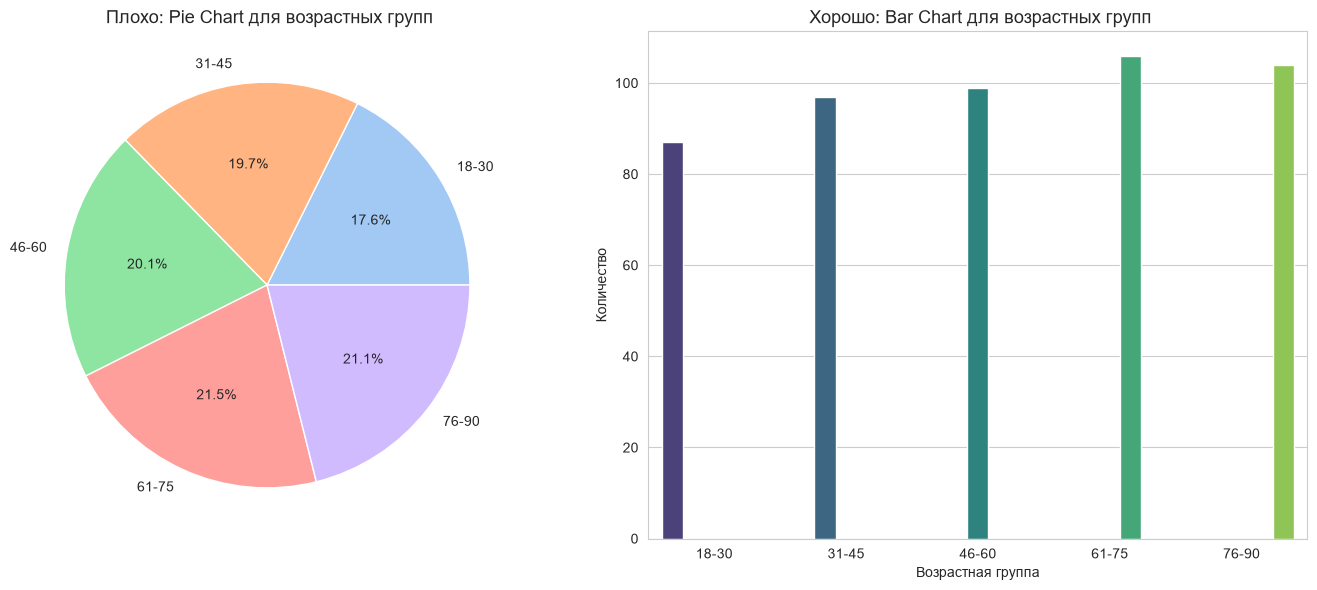

In [11]:
age_bins = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 75, 90],
    labels=['18-30', '31-45', '46-60', '61-75', '76-90']
)
counts = age_bins.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)
axes[0].set_title(' Плохо: Pie Chart для возрастных групп')

sns.barplot(
    x=counts.index,
    y=counts.values,
    ax=axes[1],
    hue=counts.index,
    palette='viridis',
    legend=False
)
axes[1].set_title(' Хорошо: Bar Chart для возрастных групп')
axes[1].set_xlabel('Возрастная группа')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()



### 7.1. Выбор визуализации
Из моей работы: **гистограмма распределения возраста**.

### 7.2. Худший тип диаграммы
**Круговая диаграмма (Pie Chart)** для возрастных групп.

### 7.3. Что бы она исказила?
- Круговая диаграмма не показывает форму распределения.
- Она скрывает порядок возрастных групп.
- Зритель может не заметить, что возраст распределён почти равномерно.
- Для непрерывных данных круговая диаграмма — плохой выбор.

## Задание 8. Одна и та же информация — разные графики

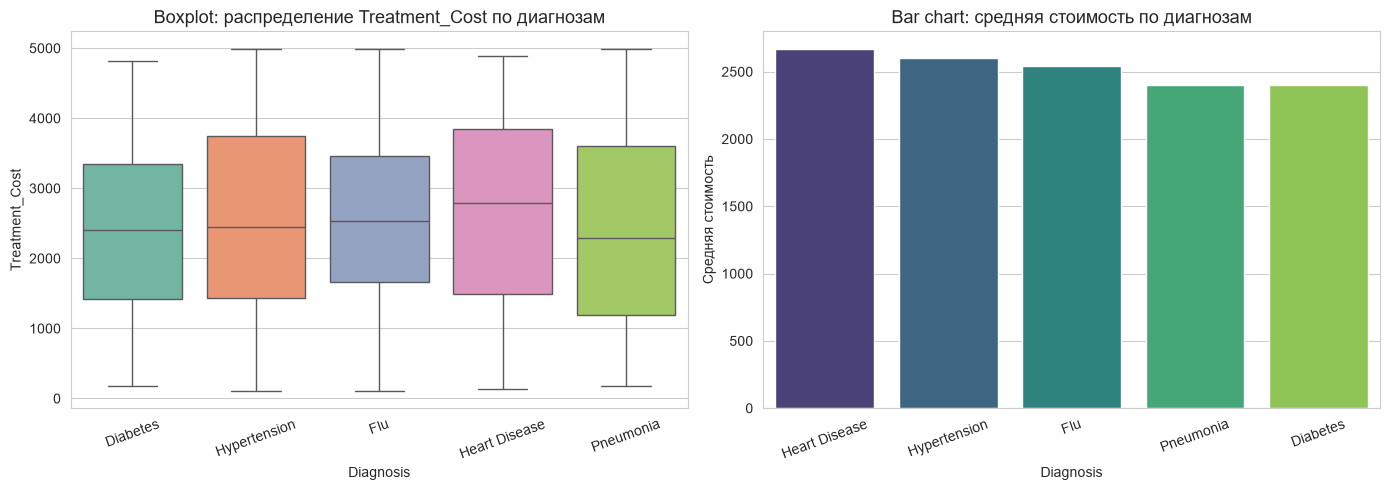

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x='Diagnosis',
    y='Treatment_Cost',
    ax=axes[0],
    hue='Diagnosis',
    palette='Set2',
    legend=False
)
axes[0].set_title('Boxplot: распределение Treatment_Cost по диагнозам')
axes[0].tick_params(axis='x', rotation=20)

mean_costs = df.groupby('Diagnosis')['Treatment_Cost'].mean().sort_values(ascending=False)
sns.barplot(
    x=mean_costs.index,
    y=mean_costs.values,
    ax=axes[1],
    hue=mean_costs.index,
    palette='viridis',
    legend=False
)
axes[1].set_title('Bar chart: средняя стоимость по диагнозам')
axes[1].set_ylabel('Средняя стоимость')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()



Пара признаков: `Diagnosis` и `Treatment_Cost`.

1. **Boxplot** — показывает распределение, медиану, разброс и выбросы по каждому диагнозу.
2. **Bar chart средних** — показывает только среднюю стоимость, скрывая разброс.

**Что подчёркивает каждый:**
- Boxplot легче заметить различия в разбросе и наличие выбросов.
- Bar chart легче сравнить средние значения между диагнозами.

**Гипотезы:**
- В boxplot видно, что разброс стоимости может быть шире для некоторых диагнозов.
- В bar chart видно, что средние стоимости близки, но могут отличаться.

## Итоговые выводы по Части 2

1. **Типы шкал:** определены шкалы для всех признаков; для номинальных признаков некорректно считать среднее и медиану.
2. **Природа пропусков:** в исходных данных пропусков нет; на симуляции показан механизм MAR.
3. **Индикатор пропуска:** объяснено, когда факт пропуска несёт информацию, а когда вреден.
4. **Выбросы:** показано, что высокие `Treatment_Cost` — скорее реальные сложные случаи, чем ошибки.
5. **Преобразования:** сравнены логарифм, корень и винизоризация.
6. **Средние:** показано, почему арифметическое, медиана и геометрическое среднее могут различаться.
7. **Визуализация:** доказано, что Pie Chart — плохой выбор для возрастных групп; показано, как Boxplot и Bar chart дают разные инсайты для одной пары признаков.